In [1]:
!pip install opencv-python torch torchvision ultralytics matplotlib pillow


Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [ ]:
import cv2
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
from IPython.display import display
from ultralytics import YOLO

# ----------------------------------------
# TẢI MODEL YOLO VÀ RESNET
# ----------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Sử dụng thiết bị: {device}")

# Tải YOLO Model
try:
    yolo_model = YOLO(r'C:\Users\Nguye\OneDrive\Desktop\money_project\money_project\runs\detect\runs\detect\train_yolo_model3\weights\best.pt')
    print('-> Đã tải YOLO Model thành công!')
except Exception as e:
    print('Lỗi tải YOLO:', e)

# Tải ResNet Model
try:
    with open('resnet_classes.txt', 'r') as f:
        class_names = f.read().split(',')
    num_classes = len(class_names)
    resnet_model = models.resnet50(weights=None)
    num_ftrs = resnet_model.fc.in_features
    resnet_model.fc = nn.Linear(num_ftrs, num_classes)
    resnet_model.load_state_dict(torch.load('best_resnet.pth', map_location=device, weights_only=True))
    resnet_model = resnet_model.to(device)
    resnet_model.eval()
    print('-> Đã tải ResNet50 Model thành công!')
except Exception as e:
    print('Lỗi tải ResNet:', e)

# Hình ảnh đầu vào
IMAGE_PATH = '.jpg'
img_bgr = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
pil_img = Image.fromarray(img_rgb)


Sử dụng thiết bị: cpu
-> Đã tải YOLO Model thành công!
-> Đã tải ResNet50 Model thành công!


--- TẦNG 1: QUÉT YOLO VÀ XÁC ĐỊNH ROI ---


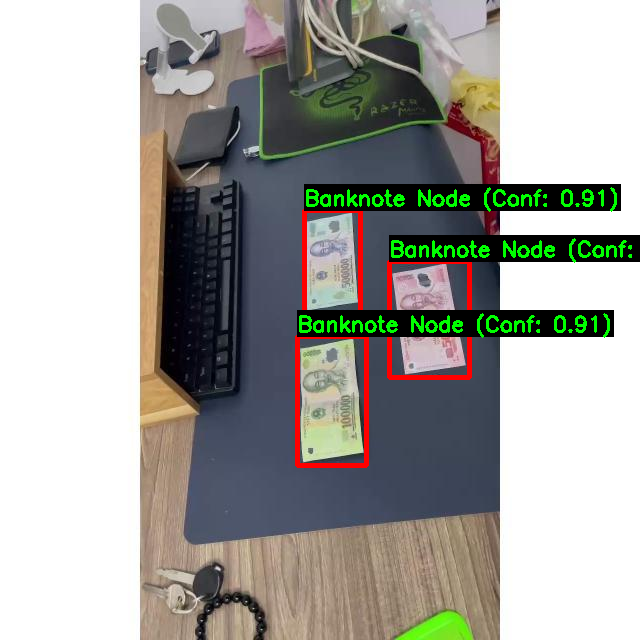

In [3]:
# ----------------------------------------
# TẦNG 1: DÙNG YOLO TÌM VỊ TRÍ KHOANH VÙNG
# ----------------------------------------
print('--- TẦNG 1: QUÉT YOLO VÀ XÁC ĐỊNH ROI ---')
results = yolo_model(img_rgb, verbose=False)
boxes = results[0].boxes

img_yolo = img_rgb.copy()
for box in boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    conf = float(box.conf[0])
    
    cv2.rectangle(img_yolo, (x1, y1), (x2, y2), (255, 0, 0), 3) # Box Màu Đỏ (RGB)
    label = f'Banknote Node (Conf: {conf:.2f})'
    (c_w, c_h), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
    
    if y1 - c_h - 10 < 0:
        bg_y1 = y1
        bg_y2 = y1 + c_h + 10
        text_y = y1 + c_h + 5
    else:
        bg_y1 = y1 - c_h - 10
        bg_y2 = y1
        text_y = y1 - 5
        
    cv2.rectangle(img_yolo, (x1, bg_y1), (x1 + c_w, bg_y2), (0, 0, 0), -1)
    cv2.putText(img_yolo, label, (x1, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

display(Image.fromarray(img_yolo))


--- TẦNG 2: TRÍCH XUẤT CÁC MẢNH ẢNH SAU KHI QUÉT ---
Mảnh cắt thứ 1:


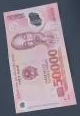

Mảnh cắt thứ 2:


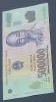

Mảnh cắt thứ 3:


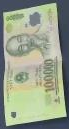

In [4]:
# ----------------------------------------
# TẦNG 2: CẮT ẢNH THEO TỌA ĐỘ BOX
# ----------------------------------------
print('--- TẦNG 2: TRÍCH XUẤT CÁC MẢNH ẢNH SAU KHI QUÉT ---')
cropped_images = []

for idx, box in enumerate(boxes):
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    crop_pil = pil_img.crop((x1, y1, x2, y2))
    cropped_images.append((crop_pil, (x1, y1, x2, y2), float(box.conf[0])))
    
    print(f'Mảnh cắt thứ {idx + 1}:')
    display(crop_pil)


--- TẦNG 3: PHÂN LOẠI MỆNH GIÁ TỪNG MẢNH VÀ HIỂN THỊ TỔNG QUAN ---
Mảnh 1 -> Nhận diện: VND_50000 (ResNet Conf: 1.00)
Mảnh 2 -> Nhận diện: VND_500000 (ResNet Conf: 1.00)
Mảnh 3 -> Nhận diện: VND_100000 (ResNet Conf: 1.00)

>>> [KẾT QUẢ] HÌNH ẢNH TOÀN DIỆN (Tương tự chạy bằng file inference.py) <<<


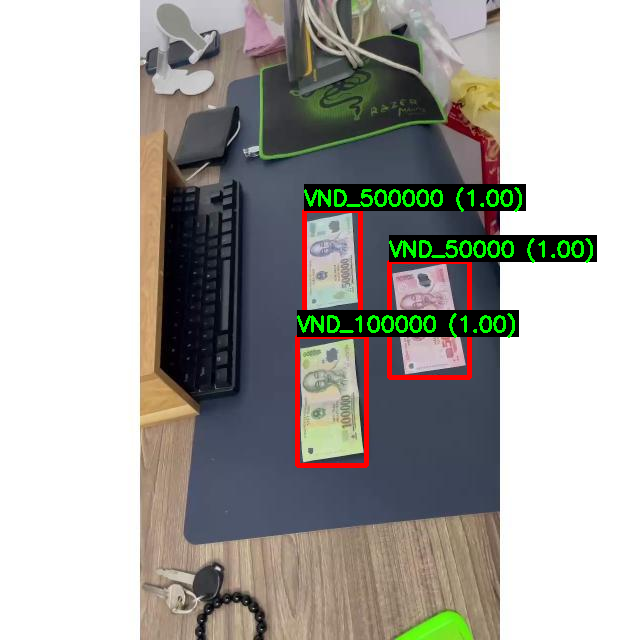

In [5]:
# ----------------------------------------
# TẦNG 3: RESNET50 ĐOÁN MỆNH GIÁ VÀ XUẤT KẾT QUẢ
# ----------------------------------------
print('--- TẦNG 3: PHÂN LOẠI MỆNH GIÁ TỪNG MẢNH VÀ HIỂN THỊ TỔNG QUAN ---')

resnet_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

img_final = img_rgb.copy()

for idx, (crop_pil, coords, yolo_conf) in enumerate(cropped_images):
    input_tensor = resnet_transforms(crop_pil).unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = resnet_model(input_tensor)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        confidence, preds = torch.max(probs, 1)
        
        predicted_class = class_names[preds[0].item()]
        conf_score = confidence.item()
        
    print(f'Mảnh {idx + 1} -> Nhận diện: {predicted_class} (ResNet Conf: {conf_score:.2f})')
    
    # Vẽ lên ảnh chuẩn bị trả về
    x1, y1, x2, y2 = coords
    cv2.rectangle(img_final, (x1, y1), (x2, y2), (255, 0, 0), 3) # Box Màu Đỏ (RGB)
    
    # Lấy nhãn cuối cùng từ inference ResNet
    # (Trùng khớp phong cách inference.py)
    label = f'{predicted_class} ({conf_score:.2f})'
    (c_w, c_h), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
    
    if y1 - c_h - 10 < 0:
        bg_y1 = y1
        bg_y2 = y1 + c_h + 10
        text_y = y1 + c_h + 5
    else:
        bg_y1 = y1 - c_h - 10
        bg_y2 = y1
        text_y = y1 - 5
        
    cv2.rectangle(img_final, (x1, bg_y1), (x1 + c_w, bg_y2), (0, 0, 0), -1) # Nền Đen
    cv2.putText(img_final, label, (x1, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2) # Chữ Màu Xanh Lá

print('\n>>> [KẾT QUẢ] HÌNH ẢNH TOÀN DIỆN (Tương tự chạy bằng file inference.py) <<<')
display(Image.fromarray(img_final))
